In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

In [18]:
ratings_base = Path("../ratings")

evaluators = ["gpt", "llama", "qwen"]
systems = ["full", "data_no_prompt", "prompt_no_data"]

def load_per_turn_csv(evaluator, system):
    if system == "full":
        path = ratings_base / evaluator / "per_turn_ratings.csv"
    else:
        path = ratings_base / evaluator / "baseline" / system / "per_turn_ratings.csv"
    
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower().str.strip()
    
    # standardize conversation id column
    if "conversation_id" not in df.columns:
        if "conversation_id" in [c.lower() for c in df.columns]:
            pass
        elif "conversation_id" not in df.columns and "conversation_id" not in df.columns:
            if "conversation_id" not in df.columns and "conversation_id" not in df.columns:
                if "conversation_id" not in df.columns and "conversation_id" not in df.columns:
                    pass
    if "conversation_id" not in df.columns:
        if "conversation_id" in df.columns:
            pass
        elif "conversation_id" not in df.columns and "conversation_id" not in df.columns:
            pass
    if "conversation_id" not in df.columns:
        # your files may use conversation_id or conversation_id-like variants
        for candidate in ["conversation_id", "conversationid", "conversation_id ", "conversation_id"]:
            if candidate in df.columns:
                df = df.rename(columns={candidate: "conversation_id"})
                break
    if "conversation_id" not in df.columns:
        for candidate in df.columns:
            if "conversation" in candidate:
                df = df.rename(columns={candidate: "conversation_id"})
                break

    # melt turn columns
    turn_cols = [c for c in df.columns if c.startswith("turn_")]
    df_long = df.melt(
        id_vars=["conversation_id"],
        value_vars=turn_cols,
        var_name="turn",
        value_name="score"
    )

    df_long["turn"] = df_long["turn"].str.extract(r"(\d+)").astype(int)
    df_long["score"] = pd.to_numeric(df_long["score"], errors="coerce")
    df_long["conversation_id"] = df_long["conversation_id"].astype(str)
    df_long["system"] = system
    df_long["evaluator"] = evaluator

    return df_long.dropna(subset=["score"])

# load all combinations
perturn_dfs = []
for evaluator in evaluators:
    for system in systems:
        try:
            tmp = load_per_turn_csv(evaluator, system)
            perturn_dfs.append(tmp)
            print(f"✓ loaded {evaluator:5s} × {system:15s}: {tmp.shape}")
        except Exception as e:
            print(f"✗ failed {evaluator:5s} × {system:15s}: {e}")

df_perturn = pd.concat(perturn_dfs, ignore_index=True)

print("\nCombined shape:", df_perturn.shape)
print(df_perturn.head())

✓ loaded gpt   × full           : (15000, 5)
✓ loaded gpt   × data_no_prompt : (15000, 5)
✓ loaded gpt   × prompt_no_data : (15000, 5)
✓ loaded llama × full           : (14997, 5)
✓ loaded llama × data_no_prompt : (15000, 5)
✓ loaded llama × prompt_no_data : (15000, 5)
✓ loaded qwen  × full           : (15090, 5)
✓ loaded qwen  × data_no_prompt : (15000, 5)
✓ loaded qwen  × prompt_no_data : (15000, 5)

Combined shape: (135087, 5)
  conversation_id  turn  score system evaluator
0        conv_000     1    8.5   full       gpt
1        conv_001     1    8.5   full       gpt
2        conv_002     1    8.5   full       gpt
3        conv_003     1    8.5   full       gpt
4        conv_004     1    9.0   full       gpt


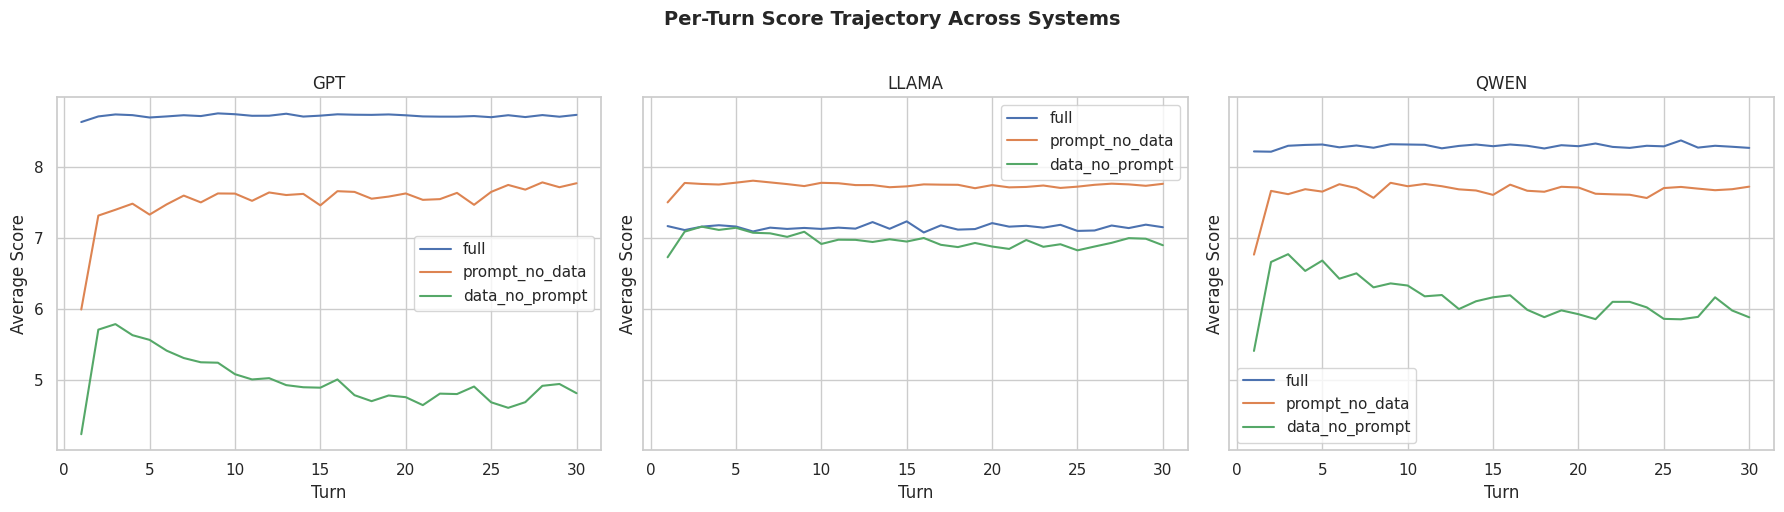

In [19]:
sns.set(style="whitegrid")

# Compute mean score per turn, per system, per evaluator
df_traj = (
    df_perturn
    .groupby(["evaluator", "system", "turn"])["score"]
    .mean()
    .reset_index()
)

# Plot: one subplot per evaluator
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

evaluators = ["gpt", "llama", "qwen"]

for ax, evaluator in zip(axes, evaluators):
    sub = df_traj[df_traj["evaluator"] == evaluator]
    
    for system in ["full", "prompt_no_data", "data_no_prompt"]:
        s = sub[sub["system"] == system]
        ax.plot(s["turn"], s["score"], label=system)
    
    ax.set_title(evaluator.upper())
    ax.set_xlabel("Turn")
    ax.set_ylabel("Average Score")
    ax.legend()

fig.suptitle("Per-Turn Score Trajectory Across Systems", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("per_turn_trajectory.png", dpi=300)
plt.show()

In [20]:
def early_late_analysis(df, evaluator, system, split=10):
    sub = df[(df["evaluator"] == evaluator) & (df["system"] == system)]
    
    early = sub[sub["turn"] <= split]["score"]
    late = sub[sub["turn"] > split]["score"]
    
    from scipy.stats import ttest_ind
    t_stat, p_val = ttest_ind(early, late, equal_var=False)
    
    return {
        "early_mean": early.mean(),
        "late_mean": late.mean(),
        "delta": late.mean() - early.mean(),
        "t_stat": t_stat,
        "p_value": p_val
    }

evaluators = ["gpt", "llama", "qwen"]
systems = ["full", "prompt_no_data", "data_no_prompt"]

for ev in evaluators:
    print(f"\n=== {ev.upper()} ===")
    for sys in systems:
        res = early_late_analysis(df_perturn, ev, sys)
        print(f"\n{sys}:")
        print(f"  Early mean: {res['early_mean']:.3f}")
        print(f"  Late mean:  {res['late_mean']:.3f}")
        print(f"  Δ (late-early): {res['delta']:.3f}")
        print(f"  p-value: {res['p_value']:.4e}")


=== GPT ===

full:
  Early mean: 8.715
  Late mean:  8.721
  Δ (late-early): 0.006
  p-value: 3.3578e-01

prompt_no_data:
  Early mean: 7.331
  Late mean:  7.620
  Δ (late-early): 0.289
  p-value: 1.3173e-23

data_no_prompt:
  Early mean: 5.317
  Late mean:  4.824
  Δ (late-early): -0.493
  p-value: 5.9288e-50

=== LLAMA ===

full:
  Early mean: 7.138
  Late mean:  7.151
  Δ (late-early): 0.013
  p-value: 3.6894e-01

prompt_no_data:
  Early mean: 7.740
  Late mean:  7.736
  Δ (late-early): -0.004
  p-value: 6.7121e-01

data_no_prompt:
  Early mean: 7.036
  Late mean:  6.923
  Δ (late-early): -0.112
  p-value: 9.4677e-14

=== QWEN ===

full:
  Early mean: 8.282
  Late mean:  8.294
  Δ (late-early): 0.012
  p-value: 3.4326e-01

prompt_no_data:
  Early mean: 7.589
  Late mean:  7.675
  Δ (late-early): 0.086
  p-value: 7.3202e-05

data_no_prompt:
  Early mean: 6.394
  Late mean:  6.012
  Δ (late-early): -0.382
  p-value: 6.1608e-28


In [21]:
# Compute per-conversation variance
df_var = (
    df_perturn
    .groupby(["evaluator", "system", "conversation_id"])["score"]
    .var()
    .reset_index()
)

# Aggregate: mean variance per system + evaluator
var_summary = (
    df_var
    .groupby(["evaluator", "system"])["score"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "avg_variance", "std": "variance_std"})
)

print(var_summary)

  evaluator          system  avg_variance  variance_std
0       gpt  data_no_prompt      3.105938      1.255418
1       gpt            full      0.098766      0.103696
2       gpt  prompt_no_data      2.171421      1.267702
3     llama  data_no_prompt      0.687193      0.144683
4     llama            full      0.624367      0.145004
5     llama  prompt_no_data      0.275589      0.205014
6      qwen  data_no_prompt      3.818924      1.827629
7      qwen            full      0.442010      0.258062
8      qwen  prompt_no_data      1.399469      0.956917


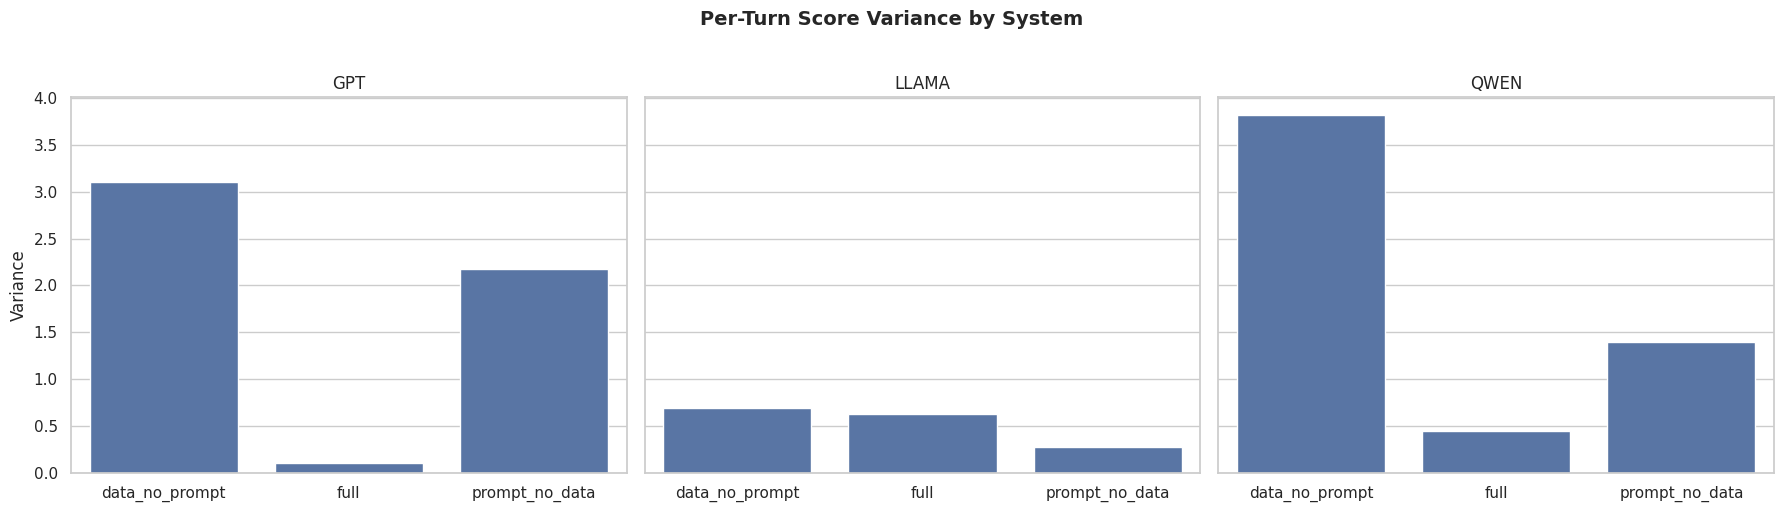

In [22]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, evaluator in zip(axes, ["gpt", "llama", "qwen"]):
    sub = var_summary[var_summary["evaluator"] == evaluator]
    
    sns.barplot(
        data=sub,
        x="system",
        y="avg_variance",
        ax=ax
    )
    
    ax.set_title(evaluator.upper())
    ax.set_xlabel("")
    ax.set_ylabel("Variance")

fig.suptitle("Per-Turn Score Variance by System", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("per_turn_variance.png", dpi=300)
plt.show()

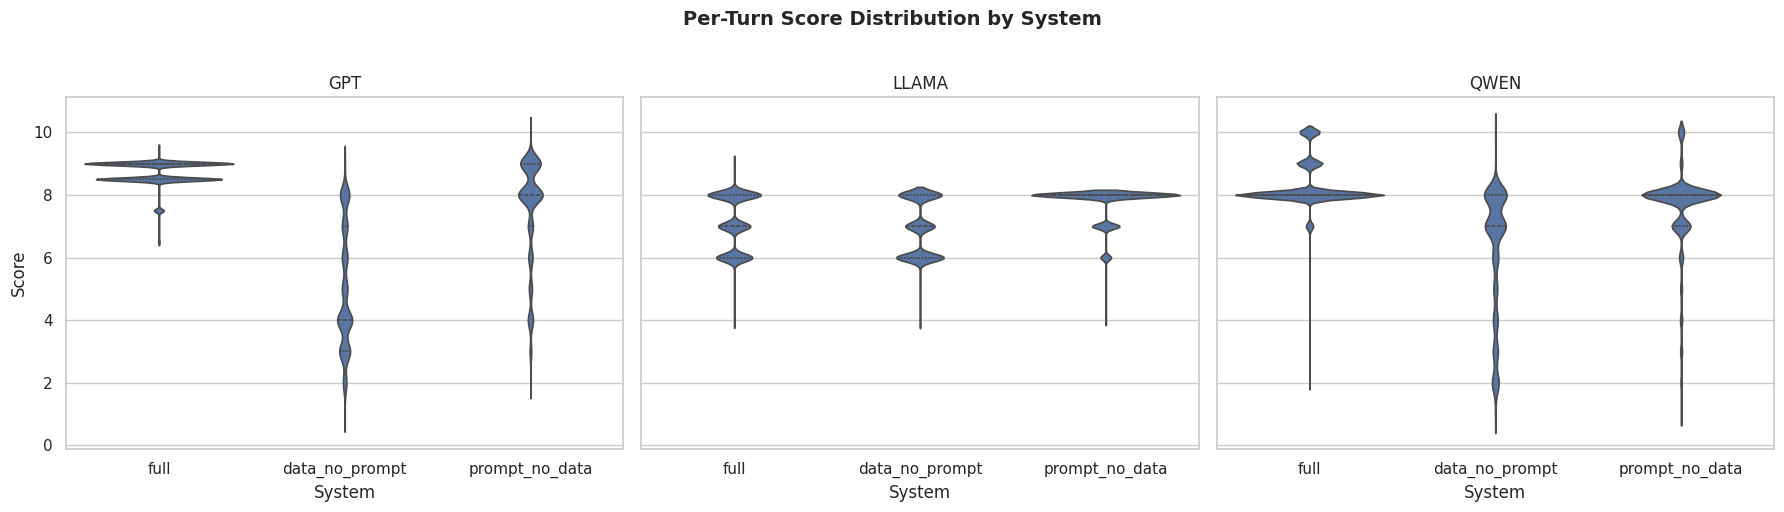

In [23]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, evaluator in zip(axes, ["gpt", "llama", "qwen"]):
    sub = df_perturn[df_perturn["evaluator"] == evaluator]
    
    sns.violinplot(
        data=sub,
        x="system",
        y="score",
        ax=ax,
        inner="quartile"
    )
    
    ax.set_title(evaluator.upper())
    ax.set_xlabel("System")
    ax.set_ylabel("Score")

fig.suptitle("Per-Turn Score Distribution by System", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("per_turn_distribution.png", dpi=300)
plt.show()